# Deep Hedging: RL Agent vs. Black-Scholes Delta Hedge

This notebook trains a **PPO** agent (Stable-Baselines3) on the `DerivativeHedgingEnv`,
then evaluates it against the analytical **Black-Scholes delta** baseline over
**1,000 test paths**.

Two comparison plots are produced:
1. **Final P&L distribution** — overlapping histograms  
2. **Path comparison** — hedge-ratio trajectories on a single sample path

## 1. Install & Import Dependencies

In [51]:
import sys, subprocess, importlib

for pkg in ["gymnasium", "stable_baselines3", "torch", "matplotlib"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               pkg if pkg != "stable_baselines3" else "stable-baselines3[extra]"])

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

print(f"torch  {torch.__version__}")
print(f"SB3 OK  |  device = {'cuda' if torch.cuda.is_available() else 'cpu'}")

torch  2.10.0
SB3 OK  |  device = cpu


## 2. Define the `DerivativeHedgingEnv`

The environment is imported from `env.py` in this workspace. Key features:
- **GBM** stock-price dynamics
- **Proportional transaction costs** (1 bp per trade)
- **Quadratic penalty** reward: $r_t = -\lambda\,(\Delta W_t)^2$
- Wealth = Cash + Stock − Option liability

In [52]:
import importlib, env as _env_module
importlib.reload(_env_module)
from env import DerivativeHedgingEnv

# Quick sanity check
test_env = DerivativeHedgingEnv()
obs, info = test_env.reset(seed=0)
print(f"Obs shape : {obs.shape}")
print(f"Obs       : {obs}")
print(f"BS delta  : {info['bs_delta']:.4f}")
print(f"Action sp : {test_env.action_space}")
del test_env

Obs shape : (6,)
Obs       : [1.         1.         0.         0.53996354 1.         0.        ]
BS delta  : 0.5400
Action sp : Box(0.0, 1.0, (1,), float32)


## 3. Instantiate Environment & Train the PPO Agent

We wrap the env in `DummyVecEnv` + `VecNormalize` and train for **200,000** timesteps.
Increase `total_timesteps` for better convergence (500k–1M recommended for production).

In [54]:
# 2M steps for converged hedging policy (can be reduced for quick testing)
TOTAL_TIMESTEPS = 2_000_000
N_ENVS = 8

def make_env():
    return DerivativeHedgingEnv()

vec_env = DummyVecEnv([make_env for _ in range(N_ENVS)])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

model = PPO(
    "MlpPolicy",
    vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.999,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=1,
    policy_kwargs=dict(net_arch=[128, 128]),
)

model.learn(total_timesteps=TOTAL_TIMESTEPS)

# save model + normalisation stats for later reuse
model.save("ppo_hedging")
vec_env.save("ppo_hedging_vecnormalize.pkl")

Using cpu device
------------------------------
| time/              |       |
|    fps             | 12463 |
|    iterations      | 1     |
|    time_elapsed    | 1     |
|    total_timesteps | 16384 |
------------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 7033         |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 32768        |
| train/                  |              |
|    approx_kl            | 0.0024674402 |
|    clip_fraction        | 0.0167       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.41        |
|    explained_variance   | -0.0288      |
|    learning_rate        | 0.0003       |
|    loss                 | 0.677        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0014      |
|    std                  | 0.993        |
|    value_loss           | 2.15   

## 4. Black-Scholes Delta Baseline

The BS delta $\Delta = N(d_1)$ is already computed inside `DerivativeHedgingEnv`
and returned in the `info` dict at every step. We simply use it as the action.

In [55]:
def run_bs_episode(env, seed):
    """Run one episode using the BS delta as the action.
    Returns (final_pnl, hedge_ratios, stock_prices)."""
    obs, info = env.reset(seed=seed)
    hedges, prices = [0.0], [env.S]

    for _ in range(env.n_steps):
        action = np.array([info["bs_delta"]], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        hedges.append(float(action[0]))
        prices.append(env.S)

    # final wealth = P&L
    return env.wealth, hedges, prices

print("BS baseline helper ready.")

BS baseline helper ready.


## 5. Evaluate on 1,000 Test Paths

Both strategies are run on **the same price paths** (same seeds) for a fair comparison.
We store per-step data for one representative path for the trajectory plot.

In [56]:
N_TEST = 1_000
#offset for seeds
SEED_OFF = 100_000

# reuse the vec_env from training in eval mode (avoids stale pkl shape mismatches)
eval_env_rl = vec_env
eval_env_rl.training = False
eval_env_rl.norm_reward = False

# raw env for BS baseline -> no normalisation
eval_env_bs = DerivativeHedgingEnv()

rl_pnls, bs_pnls = [], []
sample_rl_hedges, sample_bs_hedges, sample_prices = None, None, None
SAMPLE_IDX = 0

for i in range(N_TEST):
    seed_i = SEED_OFF + i

    # --- RL agent ---
    raw_env = eval_env_rl.venv.envs[0]
    #reset underlying env and re-seed to match BS baseline (same price path)
    obs = eval_env_rl.reset()
    raw_env.reset(seed=seed_i)
    obs = eval_env_rl.normalize_obs(raw_env._get_obs())

    rl_hedges_i, rl_prices_i = [0.0], [raw_env.S]
    for t in range(raw_env.n_steps):
        action, _ = model.predict(obs, deterministic=True)
        # action shape from predict is (1,1); flatten to (1,) for env.step
        act = action.flatten()
        raw_obs, _, _, _, info = raw_env.step(act)
        obs = eval_env_rl.normalize_obs(raw_obs)
        rl_hedges_i.append(float(np.clip(act[0], 0, 1)))
        rl_prices_i.append(raw_env.S)
    rl_pnls.append(raw_env.wealth)

    # --- BS baseline (same seed → same price path) ---
    bs_pnl, bs_hedges_i, bs_prices_i = run_bs_episode(eval_env_bs, seed=seed_i)
    bs_pnls.append(bs_pnl)

    if i == SAMPLE_IDX:
        sample_rl_hedges = rl_hedges_i
        sample_bs_hedges = bs_hedges_i
        sample_prices    = rl_prices_i

rl_pnls = np.array(rl_pnls)
bs_pnls = np.array(bs_pnls)

# --- Risk metrics ---

def risk_metrics(pnls: np.ndarray, level: float = 0.95) -> dict:
    """VaR, CVaR/ES, skewness, and excess kurtosis for a P&L array."""
    # VaR(95%): positive number = worst loss not exceeded in `level` of paths
    var = float(-np.percentile(pnls, (1 - level) * 100))

    # CVaR(95%) / Expected Shortfall: average loss in the worst (1-level) tail
    tail = pnls[pnls <= -var]
    cvar = float(-tail.mean()) if len(tail) > 0 else var

    # Skewness: negative → heavier left tail (large losses more likely)
    mu, sigma = pnls.mean(), pnls.std(ddof=1)
    skewness = float(np.mean(((pnls - mu) / sigma) ** 3))

    # Excess kurtosis: > 0 (leptokurtic) → fatter tails than Gaussian
    excess_kurt = float(np.mean(((pnls - mu) / sigma) ** 4) - 3.0)
    return {"VaR_95": var, "CVaR_95": cvar, "Skewness": skewness, "Excess_Kurtosis": excess_kurt}

rl_m = risk_metrics(rl_pnls)
bs_m = risk_metrics(bs_pnls)

header = f"{'Metric':<22s}  {'RL Agent':>12s}  {'BS Delta':>12s}"
print(header)
print("-" * len(header))
rows = [
    ("Mean P&L",         rl_pnls.mean(),         bs_pnls.mean()),
    ("Std P&L",          rl_pnls.std(),           bs_pnls.std()),
    ("VaR (95%)",        rl_m["VaR_95"],          bs_m["VaR_95"]),
    ("CVaR (95%)",       rl_m["CVaR_95"],         bs_m["CVaR_95"]),
    ("Skewness",         rl_m["Skewness"],        bs_m["Skewness"]),
    ("Excess Kurtosis",  rl_m["Excess_Kurtosis"], bs_m["Excess_Kurtosis"]),
]
for name, rv, bv in rows:
    print(f"{name:<22s}  {rv:>+12.4f}  {bv:>+12.4f}")

Metric                      RL Agent      BS Delta
--------------------------------------------------
Mean P&L                     -0.2190       -0.2125
Std P&L                      +1.0598       +0.4245
VaR (95%)                    +2.4594       +0.9398
CVaR (95%)                   +3.2620       +1.3374
Skewness                     -1.7740       -0.9760
Excess Kurtosis              +4.8938       +3.1323


## 6. Final P&L Distribution — RL vs. Black-Scholes

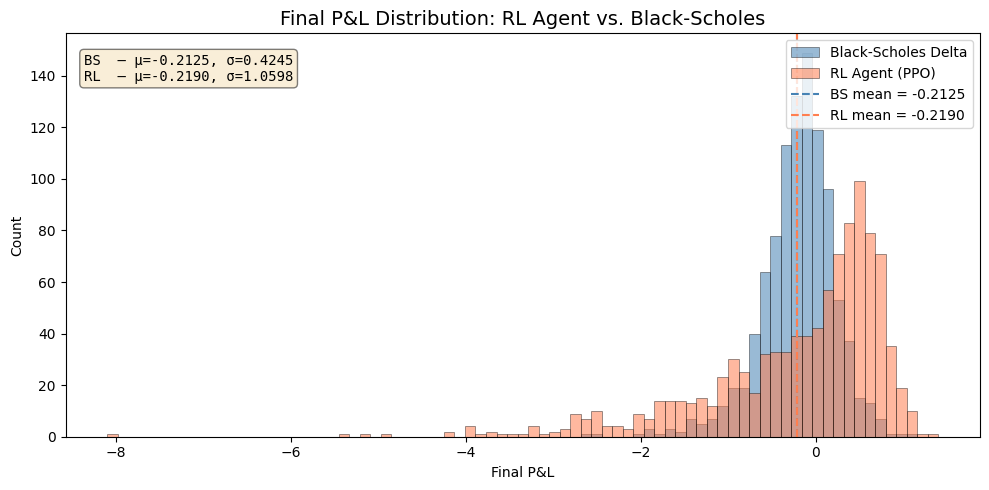

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(
    min(rl_pnls.min(), bs_pnls.min()) - 0.1,
    max(rl_pnls.max(), bs_pnls.max()) + 0.1,
    80,
)

ax.hist(bs_pnls, bins=bins, alpha=0.55, label="Black-Scholes Delta", color="steelblue", edgecolor="k", lw=0.5)
ax.hist(rl_pnls, bins=bins, alpha=0.55, label="RL Agent (PPO)",      color="coral",     edgecolor="k", lw=0.5)

ax.axvline(bs_pnls.mean(), color="steelblue", ls="--", lw=1.5, label=f"BS mean = {bs_pnls.mean():+.4f}")
ax.axvline(rl_pnls.mean(), color="coral",     ls="--", lw=1.5, label=f"RL mean = {rl_pnls.mean():+.4f}")

ax.set_title("Final P&L Distribution: RL Agent vs. Black-Scholes", fontsize=14)
ax.set_xlabel("Final P&L")
ax.set_ylabel("Count")

stats_text = (f"BS  — μ={bs_pnls.mean():+.4f}, σ={bs_pnls.std():.4f}\n"
              f"RL  — μ={rl_pnls.mean():+.4f}, σ={rl_pnls.std():.4f}")
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 7. Path Comparison: RL Hedge Ratio vs. BS Delta Over Time

A single representative path showing both hedge-ratio trajectories on the primary
y-axis and the stock price on a secondary y-axis.

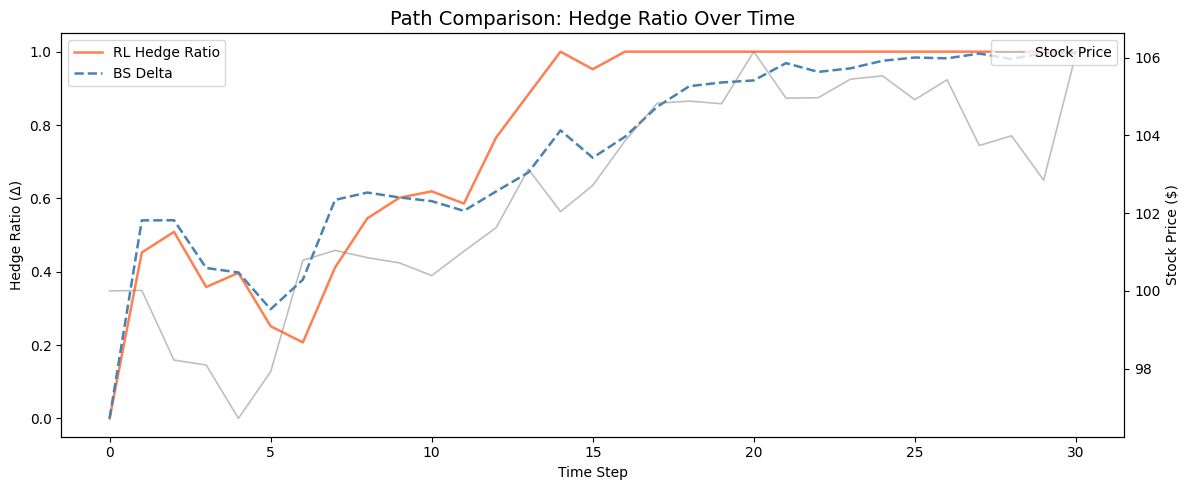

In [58]:
steps = np.arange(len(sample_rl_hedges))

fig, ax1 = plt.subplots(figsize=(12, 5))

# Hedge ratios on primary axis
ax1.plot(steps, sample_rl_hedges, label="RL Hedge Ratio", color="coral",     lw=1.8)
ax1.plot(steps, sample_bs_hedges, label="BS Delta",       color="steelblue", lw=1.8, ls="--")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Hedge Ratio (Δ)")
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc="upper left")

# Stock price on secondary axis
ax2 = ax1.twinx()
ax2.plot(steps, sample_prices, label="Stock Price", color="gray", alpha=0.5, lw=1.2)
ax2.set_ylabel("Stock Price ($)")
ax2.legend(loc="upper right")

ax1.set_title("Path Comparison: Hedge Ratio Over Time", fontsize=14)
fig.tight_layout()
plt.show()

---

## 8. Using the Standalone Scripts

The project also includes two standalone Python scripts that can be run from the command line. Below we demonstrate importing and using them directly from the notebook.

### 8a. `train_ppo.py` — CLI Training Script

`train_ppo.py` provides a `train()` function and a CLI interface for training the PPO agent. You can call it from a terminal:

```bash
python train_ppo.py --timesteps 500000 --save-path ppo_hedging
```

Or import its `train()` function directly:

In [59]:
from train_ppo import train, make_env as make_env_factory

# Example: train a fresh agent for a short run (skip if already trained above)
# Uncomment the lines below to retrain from the CLI-style function:

# retrained_model = train(total_timesteps=50_000, save_path="ppo_hedging_v2")

# You can also customise environment parameters:
# retrained_model = train(total_timesteps=100_000, save_path="ppo_high_vol", sigma=0.4, K=110)

print("train_ppo.py imported successfully.")
print("  train()      — trains PPO and saves model + VecNormalize stats")
print("  make_env()   — factory returning a callable that creates DerivativeHedgingEnv")

train_ppo.py imported successfully.
  train()      — trains PPO and saves model + VecNormalize stats
  make_env()   — factory returning a callable that creates DerivativeHedgingEnv


### 8b. `bs_benchmark.py` — Black-Scholes Benchmark Script

`bs_benchmark.py` provides a `run_bs_hedge()` function that evaluates the analytical BS delta strategy over thousands of Monte-Carlo paths. Run it from a terminal:

```bash
python bs_benchmark.py
```

Or import and use it programmatically:

=== Black-Scholes Benchmark (from bs_benchmark.py) ===
  Episodes       : 5000
  Mean final P&L : -0.0235
  Std  final P&L : 0.3563
  Mean reward    : -0.1273
  Mean tx cost   : 0.0225


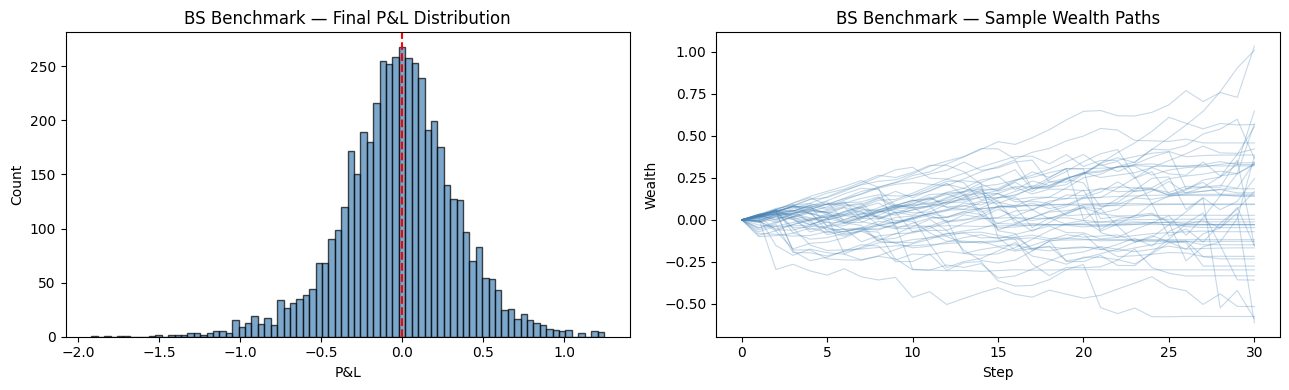

In [60]:
from bs_benchmark import run_bs_hedge

# Run the BS benchmark on 5,000 paths
bs_results = run_bs_hedge(n_episodes=5_000, seed=42)

print("=== Black-Scholes Benchmark (from bs_benchmark.py) ===")
print(f"  Episodes       : {len(bs_results['final_pnl'])}")
print(f"  Mean final P&L : {bs_results['mean_pnl']:+.4f}")
print(f"  Std  final P&L : {bs_results['std_pnl']:.4f}")
print(f"  Mean reward    : {bs_results['mean_reward']:.4f}")
print(f"  Mean tx cost   : {np.mean(bs_results['total_costs']):.4f}")

# Plot the cumulative wealth paths from the benchmark
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(bs_results["final_pnl"], bins=80, edgecolor="k", alpha=0.7, color="steelblue")
axes[0].axvline(0, color="r", ls="--")
axes[0].set_title("BS Benchmark — Final P&L Distribution")
axes[0].set_xlabel("P&L")
axes[0].set_ylabel("Count")

for j in range(min(50, len(bs_results["cumulative_pnl"]))):
    axes[1].plot(bs_results["cumulative_pnl"][j], alpha=0.3, lw=0.8, color="steelblue")
axes[1].set_title("BS Benchmark — Sample Wealth Paths")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Wealth")

plt.tight_layout()
plt.show()

### 8c. `env.py` — The Shared Environment

All scripts and this notebook import `DerivativeHedgingEnv` from `env.py`. Here's a quick demo of using it standalone:

In [61]:
from env import DerivativeHedgingEnv

# create env with custom parameters
env = DerivativeHedgingEnv(S0=100, K=105, T=60/365, sigma=0.3, r=0.02,
                           n_steps=60, transaction_cost_rate=0.002)
obs, info = env.reset(seed=123)

print("=== DerivativeHedgingEnv (from env.py) ===")
print(f"  Observation space : {env.observation_space}")
print(f"  Action space      : {env.action_space}")
print(f"  Initial obs       : S/K={obs[0]:.4f}, tau/T={obs[1]:.4f}, delta={obs[2]:.4f}, bs_delta={obs[3]:.4f}, rvol/sigma={obs[4]:.4f}, W={obs[5]:.4f}")
print(f"  BS delta (info)   : {info['bs_delta']:.4f}")
print(f"  Parameters        : S0={env.S0}, K={env.K}, T={env.T:.4f}, σ={env.sigma}, r={env.r}")
print(f"  Steps/episode     : {env.n_steps}")
print(f"  Tx cost rate      : {env.tc:.4f} ({env.tc*100:.2f}%)")

# Take one step with the BS delta
action = np.array([info["bs_delta"]], dtype=np.float32)
obs2, reward, done, trunc, info2 = env.step(action)
print(f"\n  After 1 step      : S/K={obs2[0]:.4f}, W={obs2[5]:.6f}, reward={reward:.6f}")

=== DerivativeHedgingEnv (from env.py) ===
  Observation space : Box([  0.   0.   0.   0.   0. -inf], [inf  1.  1.  1. inf inf], (6,), float32)
  Action space      : Box(0.0, 1.0, (1,), float32)
  Initial obs       : S/K=0.9524, tau/T=1.0000, delta=0.0000, bs_delta=0.3770, rvol/sigma=1.0000, W=0.0000
  BS delta (info)   : 0.3770
  Parameters        : S0=100, K=105, T=0.1644, σ=0.3, r=0.02
  Steps/episode     : 60
  Tx cost rate      : 0.0020 (0.20%)

  After 1 step      : S/K=0.9376, W=-0.076510, reward=-0.007275
